# 04 - Monitoring

This notebook monitors the email urgency classifier outputs from `data/eval.parquet`. It compares a baseline slice with a current slice, checks label/topic/confidence drift, and writes a review queue for human inspection.

In [2]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from configs.global_config import get_monitor_config
from src.emailurgency.pipelines.monitoring import ModelMonitor

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 180)
plt.style.use("seaborn-v0_8-whitegrid")

DATA_PATH = PROJECT_ROOT / "data" / "eval.parquet"
OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "monitoring"
SNAPSHOT_PATH = OUTPUT_DIR / "monitor_snapshot.json"
REVIEW_PATH = OUTPUT_DIR / "review_queue.csv"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Monitoring input:", DATA_PATH)

Project root: C:\Users\huytj\Documents\Repositories\assignment-eca-huy
Monitoring input: C:\Users\huytj\Documents\Repositories\assignment-eca-huy\data\eval.parquet


## Load Prediction Data

The monitor expects prediction columns from the evaluation pipeline: `pred`, `proba`, and optionally `topic` / `topic_probability`.

In [25]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Run evaluation first; missing {DATA_PATH}")

df = pd.read_parquet(DATA_PATH, engine="pyarrow").reset_index(drop=True)
required_columns = {"pred", "proba"}
missing = required_columns.difference(df.columns)
if missing:
    raise ValueError(f"Monitoring input is missing required columns: {sorted(missing)}")

optional_columns = [col for col in ["message_id", "date", "sender", "subject", "body", "label", "topic", "topic_probability", "threshold"] if col in df.columns]
summary = pd.DataFrame(
    {
        "rows": [len(df)],
        "columns": [len(df.columns)],
        "prediction_rate": [df["pred"].mean()],
        "mean_probability": [df["proba"].mean()],
        "min_probability": [df["proba"].min()],
        "max_probability": [df["proba"].max()],
    }
)
summary

,rows,columns,prediction_rate,mean_probability,min_probability,max_probability
0,30365,436,0.986893,0.706017,0.0,1.0


## Baseline And Current Windows

For this offline notebook, the earliest 30% of records by date is used as the baseline and the remaining records are treated as the current monitored batch. If dates are unavailable, the existing row order is used.

In [24]:
config = get_monitor_config()
monitor_df = df.copy()
if "date" in monitor_df.columns:
    monitor_df["date"] = pd.to_datetime(monitor_df["date"], errors="coerce", utc=True)
    monitor_df = monitor_df.sort_values("date", na_position="last").reset_index(drop=True)

baseline_fraction = 0.30
baseline_size = max(config.min_samples, int(len(monitor_df) * baseline_fraction))
baseline_size = min(baseline_size, max(config.min_samples, len(monitor_df) - config.min_samples))

baseline_df = monitor_df.iloc[:baseline_size].reset_index(drop=True)
current_df = monitor_df.iloc[baseline_size:].reset_index(drop=True)
if len(current_df) < config.min_samples:
    current_df = monitor_df.tail(config.min_samples).reset_index(drop=True)

print(f"Baseline rows: {len(baseline_df):,}")
print(f"Current rows: {len(current_df):,}")
print(f"Minimum samples required: {config.min_samples:,}")

Baseline rows: 9,109
Current rows: 21,256
Minimum samples required: 100


## Drift Snapshot

`ModelMonitor` compares label distribution, topic distribution, and mean model confidence against the baseline. The resulting snapshot is saved as JSON under `artifacts/monitoring/`.

In [23]:
def series_array(frame: pd.DataFrame, column: str, default=None, dtype=float):
    if column not in frame.columns:
        return default
    return frame[column].fillna(default if default is not None else 0).astype(dtype).to_numpy()

monitor = ModelMonitor(config=config)
monitor.set_baseline(
    predictions=series_array(baseline_df, "pred", 0, int),
    probabilities=series_array(baseline_df, "proba", 0.0, float),
    topics=series_array(baseline_df, "topic", -1, int) if "topic" in baseline_df.columns else None,
    topic_probabilities=series_array(baseline_df, "topic_probability", 0.0, float) if "topic_probability" in baseline_df.columns else None,
)

snapshot = monitor.monitor(
    predictions=series_array(current_df, "pred", 0, int),
    probabilities=series_array(current_df, "proba", 0.0, float),
    topics=series_array(current_df, "topic", -1, int) if "topic" in current_df.columns else None,
    topic_probabilities=series_array(current_df, "topic_probability", 0.0, float) if "topic_probability" in current_df.columns else None,
)

snapshot_dict = snapshot.model_dump()
snapshot_dict["review_queue_size"] = 0
SNAPSHOT_PATH.write_text(json.dumps(snapshot_dict, indent=2), encoding="utf-8")

pd.DataFrame(
    [
        {"metric": "sample_size", "value": snapshot.sample_size, "threshold": np.nan},
        {"metric": "label_drift_score", "value": snapshot.label_drift_score, "threshold": config.label_drift_threshold},
        {"metric": "topic_drift_score", "value": snapshot.topic_drift_score, "threshold": config.topic_drift_threshold},
        {"metric": "confidence_drift_score", "value": snapshot.confidence_drift_score, "threshold": config.confidence_drift_threshold},
        {"metric": "uncertainty_rate", "value": snapshot.uncertainty_rate, "threshold": config.uncertainty_threshold},
        {"metric": "mean_confidence", "value": snapshot.mean_confidence, "threshold": np.nan},
    ]
)

,metric,value,threshold
0,sample_size,21256.000000,NaN
1,label_drift_score,0.003461,0.15
2,topic_drift_score,0.033000,0.20
3,confidence_drift_score,0.044792,0.15
4,uncertainty_rate,0.144053,0.40
5,mean_confidence,0.719454,NaN


In [22]:
alerts = pd.DataFrame([alert.model_dump() for alert in snapshot.alerts])
if alerts.empty:
    print("No monitoring alerts triggered.")
else:
    display(alerts.sort_values(["severity", "score"], ascending=[True, False]))

No monitoring alerts triggered.


## Label And Confidence Drift

,baseline,current
not urgent,0.014821,0.012373
urgent,0.985179,0.987627


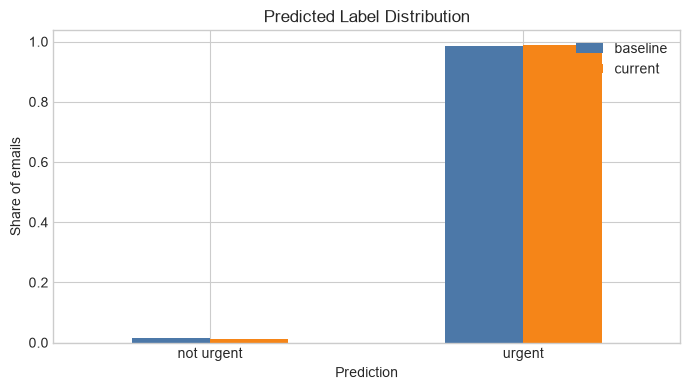

In [21]:
label_names = {0: "not urgent", 1: "urgent"}
label_compare = pd.concat(
    [
        baseline_df["pred"].value_counts(normalize=True).rename("baseline"),
        current_df["pred"].value_counts(normalize=True).rename("current"),
    ],
    axis=1,
).fillna(0.0).sort_index()
label_compare.index = [label_names.get(int(idx), str(idx)) for idx in label_compare.index]

ax = label_compare.plot(kind="bar", figsize=(7, 4), color=["#4c78a8", "#f58518"])
ax.set_title("Predicted Label Distribution")
ax.set_xlabel("Prediction")
ax.set_ylabel("Share of emails")
ax.legend(loc="upper right")
plt.xticks(rotation=0)
plt.tight_layout()
label_compare

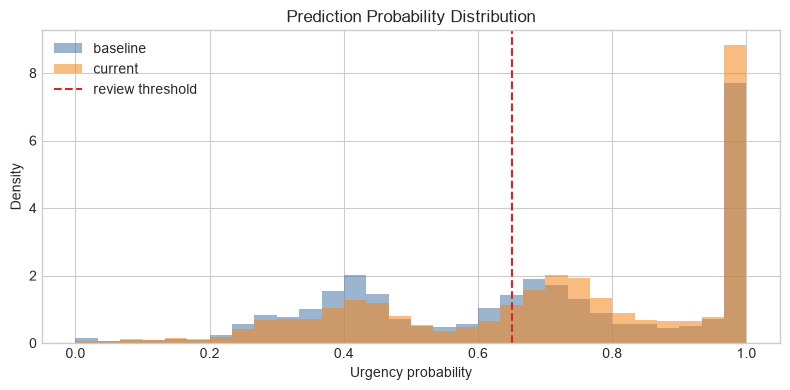

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(baseline_df["proba"].dropna(), bins=30, alpha=0.55, label="baseline", color="#4c78a8", density=True)
ax.hist(current_df["proba"].dropna(), bins=30, alpha=0.55, label="current", color="#f58518", density=True)
ax.axvline(config.review_confidence_threshold, color="#d62728", linestyle="--", linewidth=1.5, label="review threshold")
ax.set_title("Prediction Probability Distribution")
ax.set_xlabel("Urgency probability")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()

## Topic Drift

`topic = -1` is the BERTopic noise bucket. If all rows are assigned to `-1`, topic drift will be less informative and review should focus more on probability and metadata signals.

,baseline,current
topic,,
-1,0.545834,0.521406
187,0.084422,0.064546
8502,0.000000,0.001317
1186,0.000000,0.000800
392,0.000000,0.000753
6719,0.000000,0.000706
20871,0.000000,0.000706
13712,0.000000,0.000706
227,0.000659,0.000659


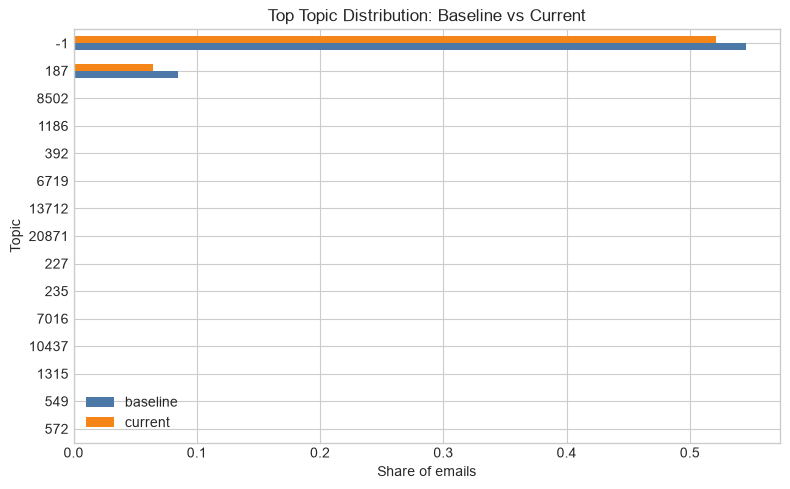

In [19]:
if "topic" in current_df.columns:
    topic_compare = pd.concat(
        [
            baseline_df["topic"].fillna(-1).astype(int).value_counts(normalize=True).rename("baseline"),
            current_df["topic"].fillna(-1).astype(int).value_counts(normalize=True).rename("current"),
        ],
        axis=1,
    ).fillna(0.0)
    top_topic_index = topic_compare.max(axis=1).sort_values(ascending=False).head(15).index
    top_topics = topic_compare.loc[top_topic_index].sort_values("current", ascending=True)

    ax = top_topics.plot(kind="barh", figsize=(8, 5), color=["#4c78a8", "#f58518"])
    ax.set_title("Top Topic Distribution: Baseline vs Current")
    ax.set_xlabel("Share of emails")
    ax.set_ylabel("Topic")
    plt.tight_layout()
    display(top_topics.sort_values("current", ascending=False))
else:
    print("No topic column available in monitoring data.")

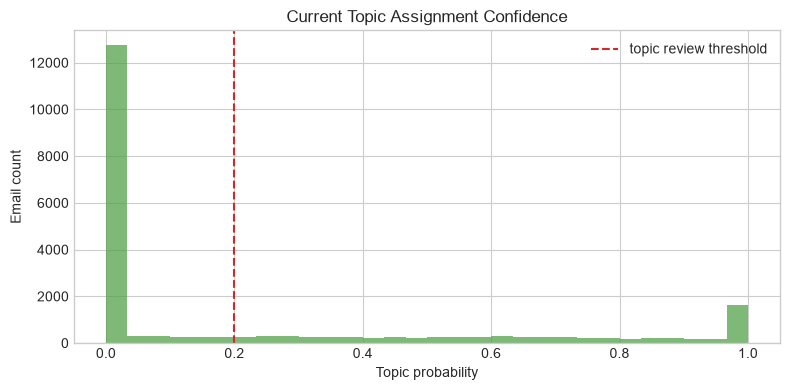

In [18]:
if "topic_probability" in current_df.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(current_df["topic_probability"].dropna(), bins=30, color="#54a24b", alpha=0.75)
    ax.axvline(0.2, color="#d62728", linestyle="--", linewidth=1.5, label="topic review threshold")
    ax.set_title("Current Topic Assignment Confidence")
    ax.set_xlabel("Topic probability")
    ax.set_ylabel("Email count")
    ax.legend()
    plt.tight_layout()
else:
    print("No topic_probability column available in monitoring data.")

## Human Review Queue

The review queue prioritizes low-confidence rows, rare topics, and uncertain topic assignments. It is saved to `artifacts/monitoring/review_queue.csv`.

In [16]:
review_items = monitor.build_review_queue(
    df=current_df.reset_index(drop=True),
    predictions=series_array(current_df, "pred", 0, int),
    probabilities=series_array(current_df, "proba", 0.0, float),
    topics=series_array(current_df, "topic", -1, int) if "topic" in current_df.columns else None,
    topic_probabilities=series_array(current_df, "topic_probability", 0.0, float) if "topic_probability" in current_df.columns else None,
    text_column="body",
    row_id_column="message_id",
)

review_df = pd.DataFrame([item.model_dump() for item in review_items])
if review_df.empty:
    review_df = pd.DataFrame(columns=["row_id", "text", "predicted_label", "predicted_probability", "topic", "topic_probability", "reason", "drift_score"])
review_df.to_csv(REVIEW_PATH, index=False)

snapshot_dict["review_queue_size"] = int(len(review_df))
SNAPSHOT_PATH.write_text(json.dumps(snapshot_dict, indent=2), encoding="utf-8")

print(f"Snapshot written to: {SNAPSHOT_PATH}")
print(f"Review queue written to: {REVIEW_PATH}")
print(f"Review queue rows: {len(review_df):,}")
review_df.head(20)

Snapshot written to: C:\Users\huytj\Documents\Repositories\assignment-eca-huy\artifacts\monitoring\monitor_snapshot.json
Review queue written to: C:\Users\huytj\Documents\Repositories\assignment-eca-huy\artifacts\monitoring\review_queue.csv
Review queue rows: 50


,row_id,text,predicted_label,predicted_probability,topic,topic_probability,reason,drift_score
0,<28419704.1075844219588.JavaMail.evans@thyme>,attached is the hb 1777 hand out that scott mentioned this morning. thanks. karen huang administrative assistant enron broadband services (503) 886-0396 desk (503) 886-0440 fax...,1,0.410108,249,0.513383,low confidence; rare topic,0.410108
1,<30085679.1075847964925.JavaMail.evans@thyme>,"steve, lou's write up is attached. the issues accepted have the effect of ""bookending"" the issue of the native load exception. on the one end, the states argue that ferc has no...",1,0.762836,-1,0.000000,uncertain topic,0.762836
2,<9187423.1075858323409.JavaMail.evans@thyme>,that's just disgusting. we had pf chang's. it was good but it keeps coming back to visit! just thought you'd like to know that. becky pitre 02/26/2001 01:51 pm to: robin rodrig...,1,0.517138,-1,0.000000,low confidence; uncertain topic,0.517138
3,<18267234.1075845668433.JavaMail.evans@thyme>,i will be in jacksonville florida this week negotiating a transaction with new jersey natural gas. it is a project development deal utilizing fuel cells. the commercial lead is...,1,0.685849,-1,0.000000,uncertain topic,0.685849
4,<8464451.1075844002462.JavaMail.evans@thyme>,"oh, i had fun as well. i'm glad you guys came. unfortunately the rest of the week was not great, but jeffrey and i met some ladies friday night and at about 2 am we all decided...",1,0.727219,-1,0.000000,uncertain topic,0.727219
5,<28726457.1075845668599.JavaMail.evans@thyme>,"no idea. whenever he gets around to it, i guess. from: suzanne on 02/26/2001 05:10 pm to: kay mann/corp/ cc: subject: re: sawgrass info well, when is your official ""start date....",1,0.994545,3709,0.185794,uncertain topic; rare topic,0.994545
6,<22430919.1075845021169.JavaMail.evans@thyme>,i think it is a good opportunity to promote standardized contracts. mark ruth ainslie 02/10/2001 05:07 pm to: mark haedicke cc: robert pickel subject: march 6 energy conference...,1,0.479456,-1,0.000000,low confidence; uncertain topic,0.479456
7,<24399872.1075845668623.JavaMail.evans@thyme>,steve: i talked with ben this afternoon and understand that we are ready to proceed with panda energy in a transaction involving the sale of member interests in special purpose...,1,0.791612,-1,0.000000,uncertain topic,0.791612
8,<18135447.1075847309098.JavaMail.evans@thyme>,"tom is the man, ditto for me! stephanie sever 02/26/2001 05:50 pm to: tom moran/hou/, tana jones/hou/, karen lambert/hou/, kelly lombardi/na/ cc: robert b cass/hou/, melba loza...",1,0.846886,-1,0.000000,uncertain topic,0.846886
9,<1270940.1075847308935.JavaMail.evans@thyme>,i believe i understand your concerns - i would like to suggest that we add the following language after the first sentence of paragraph 3 - and then execute the agreement. the ...,1,0.756348,-1,0.000000,uncertain topic,0.756348


## Review Queue Breakdown

,reason,n
0,low confidence; uncertain topic,24
1,uncertain topic,20
2,uncertain topic; rare topic,4
3,low confidence; rare topic,1
4,low confidence; uncertain topic; rare topic,1


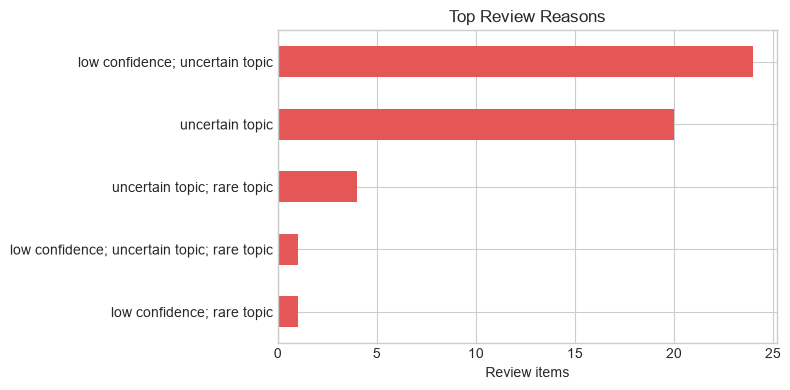

In [17]:
if not review_df.empty:
    reason_counts = review_df["reason"].value_counts().rename_axis("reason").reset_index(name="n")
    display(reason_counts)

    ax = reason_counts.head(10).sort_values("n").plot.barh(x="reason", y="n", legend=False, figsize=(8, 4), color="#e45756")
    ax.set_title("Top Review Reasons")
    ax.set_xlabel("Review items")
    ax.set_ylabel("")
    plt.tight_layout()
else:
    print("No review items generated.")

## Monitoring Summary

In [15]:
print(json.dumps(snapshot_dict, indent=2))

{
  "timestamp": "2026-07-01T06:36:35.223249+00:00",
  "sample_size": 21256,
  "label_distribution": {
    "0": 0.01237297704177644,
    "1": 0.9876270229582236
  },
  "topic_distribution": {
    "-1": 0.5214057207376741,
    "17": 0.0001881821603312006,
    "24": 0.0006115920210764019,
    "29": 0.00032931878057960106,
    "32": 4.704554008280015e-05,
    "34": 0.0005645464809936018,
    "41": 4.704554008280015e-05,
    "45": 0.0006586375611592021,
    "58": 4.704554008280015e-05,
    "62": 0.0001881821603312006,
    "63": 4.704554008280015e-05,
    "73": 0.00014113662024840045,
    "89": 4.704554008280015e-05,
    "107": 0.0003763643206624012,
    "113": 4.704554008280015e-05,
    "124": 9.40910801656003e-05,
    "127": 0.0004234098607452014,
    "137": 4.704554008280015e-05,
    "146": 0.0001881821603312006,
    "151": 0.0004704554008280015,
    "158": 4.704554008280015e-05,
    "180": 0.0001881821603312006,
    "181": 0.00023522770041400074,
    "184": 0.0003763643206624012,
    "1